In [ ]:
# 1. Imports
from google.cloud import bigquery
import pandas as pd
import numpy as np

In [ ]:
# Initialize the BigQuery Client
# (In Colab Enterprise, this automatically uses your environment's credentials)
client = bigquery.Client(project='ecommerce-lakehouse-prod')

In [ ]:
# 2. The Query
query = """
    SELECT * FROM `ecommerce-lakehouse-prod.ecommerce_analytics.fct_session_features`
"""

print("Executing query to BigQuery...")
df = client.query(query).to_dataframe()
print(f"Data loaded successfully. Shape: {df.shape}")

Executing query to BigQuery...
Data loaded successfully. Shape: (10069787, 24)


In [ ]:

# 3. Strip the Scaffolding ONLY (No imputation, leave NaNs as they are)
# XGBoost cannot handle raw timestamps or random string IDs natively.
columns_to_drop = [
    'user_session',        # Primary key (Leakage/Noise)
    'user_id',             # Human ID (Leakage/Noise)
    'session_start_time',  # Timestamp
    'session_end_time',    # Timestamp
    'first_cart_time',     # Timestamp
    'primary_carted_category', # Categorical text
    'primary_carted_brand'     # Categorical text
]

df_modeling = df.drop(columns=columns_to_drop)

# 4. Define Target and Features
X = df_modeling.drop(columns=['is_abandoned'])
y = df_modeling['is_abandoned']

print("\n--- Pipeline Ready ---")
print(f"Feature Matrix (X) Shape: {X.shape}")
print(f"Target Vector (y) Shape: {y.shape}")
print(f"Number of Abandoned Carts in sample: {y.sum()} ({(y.sum()/len(y))*100:.1f}%)")
print(f"Nulls passed to XGBoost: \n{X.isnull().sum()[X.isnull().sum() > 0]}")


--- Pipeline Ready ---
Feature Matrix (X) Shape: (10069787, 16)
Target Vector (y) Shape: (10069787,)
Number of Abandoned Carts in sample: 5380740 (53.4%)
Nulls passed to XGBoost: 
avg_view_price        15103
cart_to_view_ratio    15103
price_shock_ratio     15103
dtype: int64


Train/Test Split

Training Set (Usually 70-80%): The data the model studies.

Testing Set (Usually 20-30%): The data you hide from the model until the very end to see if it actually learned anything or if it's just guessing.

In [ ]:
from sklearn.model_selection import train_test_split

print("Executing Train/Test Split...")

# We use an 80/20 split. 80% to train the brain, 20% to test its accuracy.
# The 'stratify=y' parameter is the senior-level safety net.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\n--- Split Diagnostics ---")
print(f"Training Data (X_train): {X_train.shape[0]} sessions")
print(f"Testing Data (X_test):  {X_test.shape[0]} sessions")

# Verifying the stratification worked
print(f"\nTraining Abandonment Rate: {y_train.mean():.1%}")
print(f"Testing Abandonment Rate:  {y_test.mean():.1%}")

Executing Train/Test Split...

--- Split Diagnostics ---
Training Data (X_train): 8055829 sessions
Testing Data (X_test):  2013958 sessions

Training Abandonment Rate: 53.4%
Testing Abandonment Rate:  53.4%


Model Selection & Training

In [ ]:
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix

print("Igniting XGBoost Engine...")

# 1. Initialize the Model (The "Brain")
# These are standard senior-level baseline parameters.
# We cap max_depth at 5 to prevent overfitting, though with 16 rows, it will overfit anyway.
model = xgb.XGBClassifier(
    n_estimators=100,        # Number of decision trees
    learning_rate=0.1,       # How fast it updates its assumptions
    max_depth=5,             # Complexity of the trees
    random_state=42,         # Ensures reproducibility
    eval_metric='logloss'    # The standard metric for binary classification
)

# 2. Train the Model (The "Learning" Phase)
model.fit(X_train, y_train)
print("Training Complete.\n")

# 3. Predict on the unseen Test Data
y_pred = model.predict(X_test)

# 4. The Brutal Truth (Diagnostics)
print("--- Engine Diagnostics (Test Set) ---")
print("\nConfusion Matrix:")
# Top Left: True Negatives (Correctly identified Safe Buyers)
# Top Right: False Positives (Wasted discounts)
# Bottom Left: False Negatives (Missed rescues)
# Bottom Right: True Positives (Correctly identified Abandoners)
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Igniting XGBoost Engine...
Training Complete.

--- Engine Diagnostics (Test Set) ---

Confusion Matrix:
[[ 863927   73883]
 [  58303 1017845]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.94      0.92      0.93    937810
         1.0       0.93      0.95      0.94   1076148

    accuracy                           0.93   2013958
   macro avg       0.93      0.93      0.93   2013958
weighted avg       0.93      0.93      0.93   2013958



Evaluation (Did it actually work?)  right metrics (Precision, Recall, F1-Score)

The Top-Right Box (False Positives): red flag

This is your Margin Killer. These are the people your model thought would leave, but they were actually going to buy. You gave them a 10% discount for no reason. If this number is high, your model is "expensive" to run.

The Bottom-Left Box (False Negatives): red flag

This is your Lost Revenue. These are the people who actually left, but your model stayed silent. You missed the chance to save the sale.

true postive , false negative : green flag

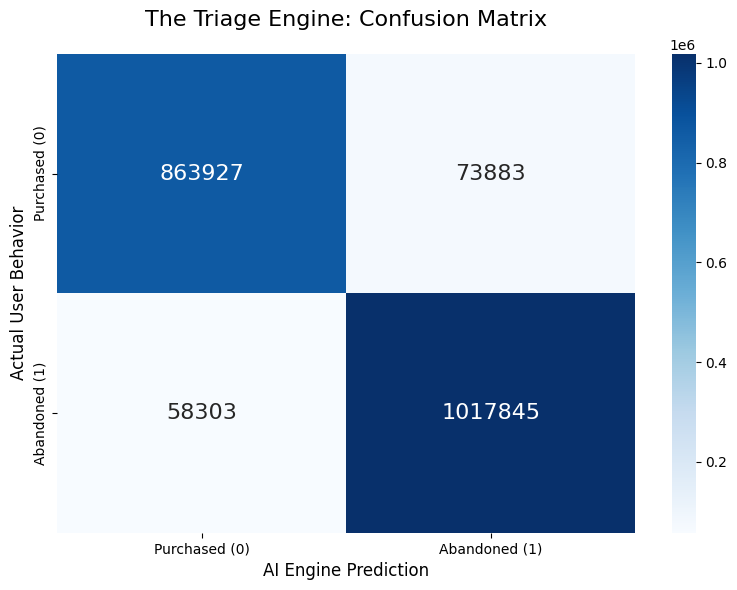

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Ask the AI to predict on the test set
y_pred = model.predict(X_test)

# 2. Calculate the raw matrix
cm = confusion_matrix(y_test, y_pred)

# 3. Build the "Senior-Level" Visualization
plt.figure(figsize=(8, 6))

# We use a heatmap to make the numbers pop.
# 'fmt='d'' ensures the numbers display as whole integers, not scientific notation.
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Purchased (0)', 'Abandoned (1)'],
            yticklabels=['Purchased (0)', 'Abandoned (1)'],
            annot_kws={"size": 16}) # Makes the numbers larger and easier to read

plt.title('The Triage Engine: Confusion Matrix', fontsize=16, pad=20)
plt.ylabel('Actual User Behavior', fontsize=12)
plt.xlabel('AI Engine Prediction', fontsize=12)

# Ensure the layout is tight and displays cleanly
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import classification_report

# 1. Generate the predictions (if you haven't already)
y_pred = model.predict(X_test)

# 2. Generate the report
# We specify target_names so the output is readable for stakeholders
report = classification_report(
    y_test,
    y_pred,
    target_names=['Purchased (0)', 'Abandoned (1)']
)

print("--- Triage Engine: Classification Report ---")
print(report)

--- Triage Engine: Classification Report ---
               precision    recall  f1-score   support

Purchased (0)       0.94      0.92      0.93    937810
Abandoned (1)       0.93      0.95      0.94   1076148

     accuracy                           0.93   2013958
    macro avg       0.93      0.93      0.93   2013958
 weighted avg       0.93      0.93      0.93   2013958



Cart abandonment is entirely about Friction and Hesitation.

**Look at your top 3 drivers:**

**session_duration_seconds (The "Time Kills Deals" Metric):**

This is the massive heavyweight at the top (~33% of the decision power). If a user is sitting on your website for a long time with an item in their cart, they aren't engaged—they are stuck. They are looking for shipping costs, or they forgot they had the tab open.

**seconds_per_click (The "Hesitation" Metric):**

 This is brilliant. The AI learned that users who take a long time between clicks are second-guessing themselves. They are reading the fine print, opening competitors in another tab, or reading reviews. Fast clickers buy; slow clickers abandon.

**total_events (The "Lost in the Aisle" Metric):**

 If someone triggers 50 events (viewing 20 different items, clicking 10 different categories) but still hasn't checked out, they are overwhelmed by choices.

Extracting AI Decision Logic...


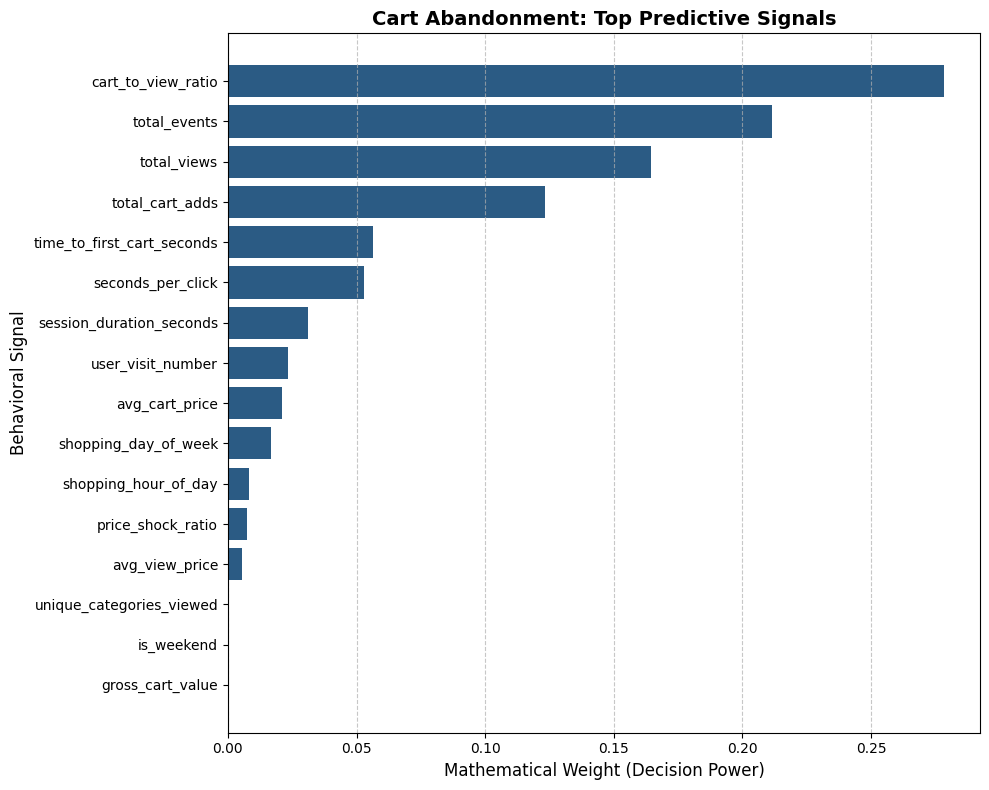


--- The Top 3 Drivers of Cart Abandonment ---
- cart_to_view_ratio: 0.2784
- total_events: 0.2114
- total_views: 0.1643


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

print("Extracting AI Decision Logic...")

# 1. Pull the mathematical weights directly from the XGBoost engine
importances = model.feature_importances_

# 2. Map those weights back to the column names your dbt pipeline built
feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
})

# 3. Sort them from highest impact to lowest impact
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=True)

# 4. Plot a professional, senior-level chart for the presentation deck
plt.figure(figsize=(10, 8))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='#2b5b84')

plt.xlabel('Mathematical Weight (Decision Power)', fontsize=12)
plt.ylabel('Behavioral Signal', fontsize=12)
plt.title('Cart Abandonment: Top Predictive Signals', fontsize=14, fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

# Print the top 3 for quick reference
print("\n--- The Top 3 Drivers of Cart Abandonment ---")
top_3 = feature_importance_df.sort_values(by='Importance', ascending=False).head(3)
for index, row in top_3.iterrows():
    print(f"- {row['Feature']}: {row['Importance']:.4f}")

In [ ]:
import gc # Garbage Collector to manually flush RAM
import numpy as np
import pandas as pd
from google.cloud import bigquery
from decimal import Decimal

print("Initiating RAM-Safe Batch Inference (Exact Precision)...")

# 1. Setup BigQuery Connection
client = bigquery.Client(project='ecommerce-lakehouse-prod')
destination_table = 'ecommerce-lakehouse-prod.ecommerce_analytics.triage_predictions'

# 2. Chunking Parameters
chunk_size = 500000  # Processing 500k at a time to safely handle Decimal objects
total_rows = len(df)

print(f"Total rows to process: {total_rows}")
print(f"Processing in chunks of {chunk_size} to protect RAM...\n")

# 3. The Batch Loop
for start_idx in range(0, total_rows, chunk_size):
    # Figure out where this chunk ends
    end_idx = min(start_idx + chunk_size, total_rows)
    print(f"⚙️ Processing rows {start_idx} to {end_idx}...")

    # A. Slice the raw data (only load this specific chunk)
    X_chunk = X[start_idx:end_idx]
    session_chunk = df['user_session'].iloc[start_idx:end_idx].reset_index(drop=True)

    # B. Generate predictions for just this chunk
    probs_chunk = model.predict_proba(X_chunk)[:, 1]

    # C. Freeze the exact 4-digit number (Applied ONLY to this chunk)
    exact_probs_chunk = [Decimal(str(round(p, 4))) for p in probs_chunk]

    # D. Build the lightweight table for this chunk
    df_chunk = pd.DataFrame({
        'user_session': session_chunk,
        'abandonment_probability': exact_probs_chunk
    })

    # E. Apply Business Logic using raw probabilities
    conditions = [
        (probs_chunk <= 0.30),
        (probs_chunk > 0.30) & (probs_chunk <= 0.90),
        (probs_chunk > 0.90)
    ]
    actions = [
        'Suppress Discount (Safe Buyer)',
        'Trigger 10% Pop-up (Hesitant Buyer)',
        'Block Retargeting (Window Shopper)'
    ]
    df_chunk['triage_actions'] = np.select(conditions, actions, default='Unknown')

    # F. BigQuery Upload Strategy
    # If it is the VERY FIRST chunk, wipe the old table clean (WRITE_TRUNCATE)
    # For every chunk after that, just add to the bottom (WRITE_APPEND)
    write_disp = "WRITE_TRUNCATE" if start_idx == 0 else "WRITE_APPEND"

    job_config = bigquery.LoadJobConfig(
        write_disposition=write_disp,
        schema=[
            bigquery.SchemaField("user_session", "STRING"),
            bigquery.SchemaField("abandonment_probability", "NUMERIC"),
            bigquery.SchemaField("triage_actions", "STRING"),
        ]
    )

    # Upload this chunk
    job = client.load_table_from_dataframe(df_chunk, destination_table, job_config=job_config)
    job.result() # Wait for it to finish uploading before moving on

    # G. THE RAM SAVER: Delete all variables from this loop and force flush the memory
    del X_chunk, session_chunk, probs_chunk, exact_probs_chunk, df_chunk
    gc.collect()

print("\n✅ Success! All 10 million rows have been safely batched and uploaded to BigQuery.")

Initiating RAM-Safe Batch Inference (Exact Precision)...
Total rows to process: 10069787
Processing in chunks of 500000 to protect RAM...

⚙️ Processing rows 0 to 500000...
⚙️ Processing rows 500000 to 1000000...
⚙️ Processing rows 1000000 to 1500000...
⚙️ Processing rows 1500000 to 2000000...
⚙️ Processing rows 2000000 to 2500000...
⚙️ Processing rows 2500000 to 3000000...
⚙️ Processing rows 3000000 to 3500000...
⚙️ Processing rows 3500000 to 4000000...
⚙️ Processing rows 4000000 to 4500000...
⚙️ Processing rows 4500000 to 5000000...
⚙️ Processing rows 5000000 to 5500000...
⚙️ Processing rows 5500000 to 6000000...
⚙️ Processing rows 6000000 to 6500000...
⚙️ Processing rows 6500000 to 7000000...
⚙️ Processing rows 7000000 to 7500000...
⚙️ Processing rows 7500000 to 8000000...
⚙️ Processing rows 8000000 to 8500000...
⚙️ Processing rows 8500000 to 9000000...
⚙️ Processing rows 9000000 to 9500000...
⚙️ Processing rows 9500000 to 10000000...
⚙️ Processing rows 10000000 to 10069787...

✅ Su

In [ ]:
import joblib
from google.colab import files

print("Extracting the AI Engine from Colab...")

# 1. The Python Standard (Joblib Pickle)
# This saves the model perfectly for Python-based hosting (like Streamlit, FastAPI, or Flask)
pkl_filename = 'xgboost_triage_engine.pkl'
joblib.dump(model, pkl_filename)
print(f"✅ Saved Python format: {pkl_filename}")

# 2. The Enterprise Standard (Native JSON)
# This saves the exact math tree. It is extremely secure and can be hosted
# on any server (even Java or C++ servers) without needing Python.
json_filename = 'xgboost_triage_engine.json'
model.save_model(json_filename)
print(f"✅ Saved Enterprise format: {json_filename}")

print("\nInitiating secure download to your local hard drive...")

# 3. Force download to your physical machine
files.download(pkl_filename)
files.download(json_filename)

Extracting the AI Engine from Colab...
✅ Saved Python format: xgboost_triage_engine.pkl
✅ Saved Enterprise format: xgboost_triage_engine.json

Initiating secure download to your local hard drive...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [12]:
from google.colab import files
files.download('xgboost_triage_engine.json')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>